Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.7229
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9496
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1868
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5668
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3146
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Input : [ 4  3 10  6  3 19]
Target: [19  3  6 10  3  4]


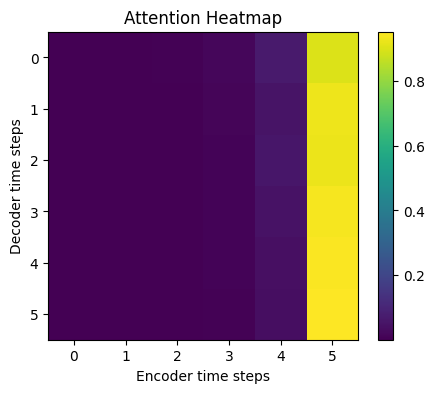

In [1]:
# =========================
# IMPORTS
# =========================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate
from tensorflow.keras.models import Model

# =========================
# PARAMETERS
# =========================
num_samples = 4000
max_len = 6
vocab_size = 20
latent_dim = 128
embedding_dim = 64

# =========================
# SYNTHETIC SEQ2SEQ DATA (reverse sequence)
# =========================
def generate_data(n):
    enc_in, dec_in, dec_out = [], [], []
    for _ in range(n):
        seq = np.random.randint(1, vocab_size, size=max_len)
        rev = seq[::-1]
        enc_in.append(seq)
        dec_in.append(np.insert(rev[:-1], 0, 0))  # start token = 0
        dec_out.append(rev)
    return np.array(enc_in), np.array(dec_in), np.array(dec_out)

encoder_input, decoder_input, decoder_output = generate_data(num_samples)

# =========================
# MODEL: Encoder–Decoder + Attention
# =========================
# Encoder
enc_inputs = Input(shape=(max_len,))
enc_emb = Embedding(vocab_size, embedding_dim)(enc_inputs)
enc_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
enc_out, h, c = enc_lstm(enc_emb)

# Decoder
dec_inputs = Input(shape=(max_len,))
dec_emb = Embedding(vocab_size, embedding_dim)(dec_inputs)
dec_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
dec_out, _, _ = dec_lstm(dec_emb, initial_state=[h, c])

# Attention (Additive/Bahdanau-style)
attn = tf.keras.layers.AdditiveAttention(name="attention")
context, attn_scores = attn([dec_out, enc_out], return_attention_scores=True)

# Combine + output
concat = Concatenate()([dec_out, context])
out = Dense(vocab_size, activation='softmax')(concat)

model = Model([enc_inputs, dec_inputs], out)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# =========================
# TRAIN
# =========================
model.fit(
    [encoder_input, decoder_input],
    np.expand_dims(decoder_output, -1),
    epochs=5,
    batch_size=64,
    verbose=1
)

# =========================
# MODEL TO EXTRACT ATTENTION
# =========================
attn_model = Model([enc_inputs, dec_inputs], attn_scores)

# =========================
# TEST SAMPLE
# =========================
sample_enc = encoder_input[0:1]
sample_dec = decoder_input[0:1]

scores = attn_model.predict([sample_enc, sample_dec])[0]  # (dec_steps, enc_steps)

print("Input :", sample_enc[0])
print("Target:", decoder_output[0])

# =========================
# HEATMAP
# =========================
plt.figure(figsize=(5,4))
plt.imshow(scores, aspect='auto')
plt.colorbar()
plt.xlabel("Encoder time steps")
plt.ylabel("Decoder time steps")
plt.title("Attention Heatmap")
plt.show()

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 2.1475
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6538
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2800
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1631
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1071
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0786
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0633
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0459
Epoch 9/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0364
Epoch 10/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0333
Epoch 11/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0327
Epoch 12/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0277
Epoch 13/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0217
Epoch 14/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0169
Epoch 15/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - 

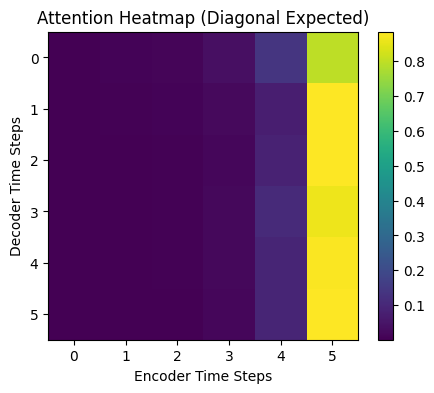

In [2]:
# =========================
# IMPORTS
# =========================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate
from tensorflow.keras.models import Model

# =========================
# PARAMETERS (tuned for convergence)
# =========================
num_samples = 12000
max_len = 6
vocab_size = 20
latent_dim = 64
embedding_dim = 64

# =========================
# DATA (reverse sequence)
# =========================
def generate_data(n):
    enc_in, dec_in, dec_out = [], [], []
    for _ in range(n):
        seq = np.random.randint(1, vocab_size, size=max_len)
        rev = seq[::-1]

        enc_in.append(seq)
        dec_in.append(np.insert(rev[:-1], 0, 0))  # start token
        dec_out.append(rev)

    return np.array(enc_in), np.array(dec_in), np.array(dec_out)

encoder_input, decoder_input, decoder_output = generate_data(num_samples)

# =========================
# MODEL
# =========================

# Encoder
encoder_inputs = Input(shape=(max_len,))
enc_emb = Embedding(vocab_size, embedding_dim)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# Decoder
decoder_inputs = Input(shape=(max_len,))
dec_emb = Embedding(vocab_size, embedding_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# Attention
attention = tf.keras.layers.AdditiveAttention(name="attention")
context, attention_weights = attention(
    [decoder_outputs, encoder_outputs],
    return_attention_scores=True
)

# Combine
concat = Concatenate()([decoder_outputs, context])

# Output
outputs = Dense(vocab_size, activation='softmax')(concat)

# Model
model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# =========================
# TRAIN (IMPORTANT: enough epochs)
# =========================
model.fit(
    [encoder_input, decoder_input],
    np.expand_dims(decoder_output, -1),
    epochs=15,
    batch_size=64,
    verbose=1
)

# =========================
# ATTENTION MODEL
# =========================
attn_model = Model([encoder_inputs, decoder_inputs], attention_weights)

# =========================
# TEST SAMPLE
# =========================
sample_enc = encoder_input[0:1]
sample_dec = decoder_input[0:1]

attn = attn_model.predict([sample_enc, sample_dec])[0]

print("Input :", sample_enc[0])
print("Target:", decoder_output[0])

# =========================
# HEATMAP
# =========================
plt.figure(figsize=(5,4))
plt.imshow(attn, aspect='auto')
plt.colorbar()

plt.xlabel("Encoder Time Steps")
plt.ylabel("Decoder Time Steps")
plt.title("Attention Heatmap (Diagonal Expected)")

plt.show()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 6, 64)     │      1,280 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 6, 64)     │      1,280 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 6, 64),   │     33,024 │ embedding_4[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 6, 64),   │     33,024 │ embedding_5[0][0… │
│                     │ (None, 64),       │            │ lstm_4[0][1],     │
│                     │ (None, 64)]       │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 6, 6)      │          0 │ lstm_5[0][0],     │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 6, 6)      │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 6, 64)     │          0 │ attention_weight… │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 6, 128)    │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ dot_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6, 20)     │      2,580 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 71,188 (278.08 KB)

 Trainable params: 71,188 (278.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.1041
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4149
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0879
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0383
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0208
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0160
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0052
Epoch 9/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0038
Epoch 10/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0030
Epoch 11/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0024
Epoch 12/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0021
Epoch 13/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016
Epoch 14/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013
Epoch 15/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - 

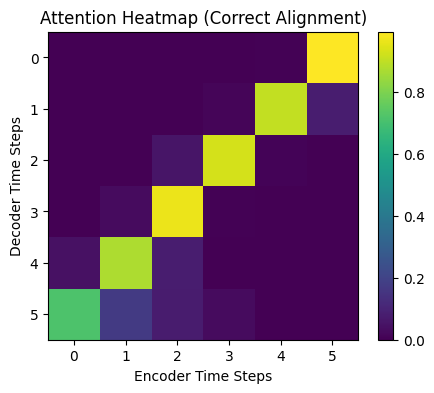

In [3]:
# =========================
# IMPORTS
# =========================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dot, Activation
from tensorflow.keras.models import Model

# =========================
# PARAMETERS
# =========================
num_samples = 12000
max_len = 6
vocab_size = 20
latent_dim = 64
embedding_dim = 64

# =========================
# DATA (reverse sequence)
# =========================
def generate_data(n):
    enc_in, dec_in, dec_out = [], [], []
    for _ in range(n):
        seq = np.random.randint(1, vocab_size, size=max_len)
        rev = seq[::-1]

        enc_in.append(seq)
        dec_in.append(np.insert(rev[:-1], 0, 0))  # start token
        dec_out.append(rev)

    return np.array(enc_in), np.array(dec_in), np.array(dec_out)

encoder_input, decoder_input, decoder_output = generate_data(num_samples)

# =========================
# MODEL
# =========================

# Encoder
encoder_inputs = Input(shape=(max_len,))
enc_emb = Embedding(vocab_size, embedding_dim)(encoder_inputs)

encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

# Decoder
decoder_inputs = Input(shape=(max_len,))
dec_emb = Embedding(vocab_size, embedding_dim)(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

# =========================
# 🔥 DOT-PRODUCT ATTENTION (FIX)
# =========================

# score = decoder ⋅ encoder
score = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])

# normalize → attention weights
attention_weights = Activation('softmax', name="attention_weights")(score)

# context = weights ⋅ encoder outputs
context = Dot(axes=[2, 1])([attention_weights, encoder_outputs])

# =========================
# COMBINE + OUTPUT
# =========================
concat = Concatenate()([decoder_outputs, context])
outputs = Dense(vocab_size, activation='softmax')(concat)

# =========================
# MODEL COMPILE
# =========================
model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.summary()

# =========================
# TRAIN
# =========================
model.fit(
    [encoder_input, decoder_input],
    np.expand_dims(decoder_output, -1),
    epochs=15,
    batch_size=64,
    verbose=1
)

# =========================
# ATTENTION MODEL
# =========================
attn_model = Model(
    [encoder_inputs, decoder_inputs],
    attention_weights
)

# =========================
# TEST SAMPLE
# =========================
sample_enc = encoder_input[0:1]
sample_dec = decoder_input[0:1]

attn = attn_model.predict([sample_enc, sample_dec])[0]

print("Input :", sample_enc[0])
print("Target:", decoder_output[0])

# =========================
# HEATMAP
# =========================
plt.figure(figsize=(5,4))
plt.imshow(attn, aspect='auto')
plt.colorbar()

plt.xlabel("Encoder Time Steps")
plt.ylabel("Decoder Time Steps")
plt.title("Attention Heatmap (Correct Alignment)")

plt.show()